In [2]:
#Forzamos la instalación de Jinja2 en el entorno del Kernel activo para asegurar que esté disponible para este cuaderno.
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
print("🎯 El cuaderno está ejecutando este Python:")
print(sys.executable)

try:
    import jinja2
    print("✅ ¡Perfecto! Jinja2 ya es visible dentro de este cuaderno.")
except ImportError:
    print("❌ Error: Este Kernel sigue sin ver Jinja2. Está apuntando al Python global.")

🎯 El cuaderno está ejecutando este Python:
c:\Users\jovic\JCProjectsDA\JC_EDA_ProyectoFinal\.venv\Scripts\python.exe
✅ ¡Perfecto! Jinja2 ya es visible dentro de este cuaderno.


**1. Configuración  inicial**

A. Revisamos el entorno y creamos la conexión a la base de datos con archivo .env  que contiene las credenciales.

ATENCION: Para replicar: 🚧 se debe crear archivo .env con la información en la raiz de proyecto

B. Creamos la función para guardar plots como imagen '.png'.

In [4]:

#A. Creamos la conexión a la base de datos con archivo .env 
#  que contiene las credenciales.
#---------------------------------------------------
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text


# 1. Cargamos de forma segura las variables de entorno desde el archivo .env
load_dotenv()

# 2. Recuperamos las credenciales del entorno aislado
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")

# 3. Construimos la URL de conexión exacta
connection_string = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# 4. Inicializar el motor de SQLAlchemy
engine = create_engine(connection_string)

print(f"Conexión exitosa al motor de PostgreSQL.")
print(f"Base de datos activa y enlazada: '{DB_NAME}' ✨")

Conexión exitosa al motor de PostgreSQL.
Base de datos activa y enlazada: 'ecom_analytics' ✨


In [5]:

#B. FUNCIÓN MAESTRA DE EXPORTACIÓN DE PLOTS (PNG)
#---------------------------------------------------
def guardar_grafica(nombre_archivo, carpeta="../reports/figuras"):
    """
    Exporta la gráfica activa de Matplotlib/Seaborn de forma automatizada.
    
    ¿Qué hace este código paso a paso?
    1. os.path.exists/makedirs: Comprueba si la carpeta física existe; 
       si no, la crea automáticamente para evitar errores de ruta.
    2. os.path.join: Une de forma limpia la carpeta con el nombre del archivo (ej. 'outliers_amount.png').
    3. plt.savefig: Guarda el archivo con 300 DPI (alta resolución) y 
       'bbox_inches=tight' para evitar que se corten los textos de los ejes.
    """
    # Validar o crear el directorio de destino
    if not os.path.exists(carpeta):
        os.makedirs(carpeta)
        print(f"📁 Infraestructura: Carpeta creada automáticamente en '{carpeta}'")
    
    # Construir la ruta final del archivo de imagen
    ruta_completa = os.path.join(carpeta, nombre_archivo)
    
    # Guardar el lienzo con  alta resolución y ajuste de bordes
    plt.savefig(ruta_completa, bbox_inches='tight', dpi=300)
    print(f"💾 Éxito: Gráfica exportada correctamente en: {ruta_completa}")

**2. Carga de las Fuentes en Bruto desde 'raw'**

Leemos los dos archivos independientes de Kaggle.
Repositorio empaquetado por The Devastator en kaggle: 
Contiene la actividad de transacciones y operativa real de una corporación de comercio electrónico (focalizada en retail de moda y distribución omnicanal).

Usamos el parámetro low_memory=False para evitar que Pandas indique fallas por la asimetría de tipos de datos en columnas masivas mientras escanea las más de 128.000 filas.

Dos archivos .csv con estructuras similares pero con diferencias en los nombres de columnas y formatos de fecha, lo que requerirá un proceso de limpieza y estandarización para su posterior análisis.

* Amazon Sale Report.csv: Contiene datos de ventas con columnas como 'Order ID', 'Product Name', 'Quantity', 'Price', 'Order Date', etc.
* Sale Report.csv: Contiene datos de catálogo de productos con columnas como 'Product ID',



In [6]:
import pandas as pd
import numpy as np
import warnings


#warnings.filterwarnings('ignore') lo mantenemos inactivo , a menos que veamos mucho ruido de advertencias durante la carga de datos, en cuyo caso podríamos activarlo.


In [7]:

# 1. Cargamos el dataset transaccional masivo de Amazon
df_amazon = pd.read_csv("../data/raw/Amazon Sale Report.csv", low_memory=False)

# 2. Cargamos la tabla maestra del catálogo de productos (Precios base)
df_catalogo = pd.read_csv("../data/raw/Sale Report.csv", low_memory=False)

# 3. Imprimimos el diagnóstico inicial de la estructura de ambas fuentes
print(f" FUENTE A 🎰 (Transacciones) - Filas: {df_amazon.shape[0]:,} | Columnas: {df_amazon.shape[1]}")
print(f" FUENTE B 📂 (Catálogo Maestro) - Filas: {df_catalogo.shape[0]:,} | Columnas: {df_catalogo.shape[1]}")

 FUENTE A 🎰 (Transacciones) - Filas: 128,975 | Columnas: 24
 FUENTE B 📂 (Catálogo Maestro) - Filas: 9,271 | Columnas: 7


In [8]:
import pandas as pd
import numpy as np
import warnings

#warnings.filterwarnings('ignore') lo mantenemos inactivo , a menos que veamos mucho ruido de advertencias durante la carga de datos, en cuyo caso podríamos activarlo.

# 1. Cargamos el dataset transaccional masivo de Amazon
df_amazon = pd.read_csv("../data/raw/Amazon Sale Report.csv", low_memory=False)

# 2. Cargamos la tabla maestra del catálogo de productos (Precios base)
df_catalogo = pd.read_csv("../data/raw/Sale Report.csv", low_memory=False)

# 3. Imprimimos el diagnóstico inicial de la estructura de ambas fuentes
print(f" FUENTE A 🎰 (Transacciones) - Filas: {df_amazon.shape[0]:,} | Columnas: {df_amazon.shape[1]}")
print(f" FUENTE B 📂 (Catálogo Maestro) - Filas: {df_catalogo.shape[0]:,} | Columnas: {df_catalogo.shape[1]}")

 FUENTE A 🎰 (Transacciones) - Filas: 128,975 | Columnas: 24
 FUENTE B 📂 (Catálogo Maestro) - Filas: 9,271 | Columnas: 7


**3. Diagnóstico Estructural y Huella de Memoria Inicial**

 A. Realizamos una inspección de los datatype (dtype) asignado automáticamente por Python a cada columna y medimos cuánta memoria RAM en megabytes (MB) está consumiendo el dataset transaccional en su estado inicial.

In [9]:
# 1. Analizamos tipos de datos automáticos de la fuente masiva de Amazon
print("🔍 --- DIAGNÓSTICO DE TIPOS DE DATOS DE LA FUENTE (df_amazon) ---")
print(df_amazon.dtypes)

# 2. Calcular el consumo real de memoria RAM que exige este dataset en bruto
memoria_inicial_mb = df_amazon.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"\n💾 memoria RAM inicial de df_amazon: {memoria_inicial_mb:.2f} MB")

🔍 --- DIAGNÓSTICO DE TIPOS DE DATOS DE LA FUENTE (df_amazon) ---
index                   int64
Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
ship-state                str
ship-postal-code      float64
ship-country              str
promotion-ids             str
B2B                      bool
fulfilled-by              str
Unnamed: 22            object
dtype: object

💾 memoria RAM inicial de df_amazon: 85.51 MB


B. Tabla Maestra de Calidad de Datos

Diccionario de Fuentes: Agrupamos los dos DataFrames en un diccionario asignándoles una etiqueta clara de su archivo de origen.

Bucle de Extracción: Iteramos columna por columna analizando su tipo de dato nativo (dtype) y sus valores únicos.

Contador de NaN vs Unknown: Contamos los nulos reales del sistema (.isna()), pero además aplicamos un filtro de texto para cazar registros que contienen la palabra "unknown" escrita de cualquier forma (mayúsculas, minúsculas o con espacios), lo cual es un nulo encubierto muy común en el software transaccional.

Muestreo Inteligente (Sample): Extraemos los primeros 10 elementos únicos de cada columna, ignorando los nulos, para tener una vista rápida del tipo de contenido real de la variable.

Dummies / Centinelas (valores Dummy): "trucos" del sistema del tipo

* 1900-01-01 o 1970-01-01: Para representar un valor que en realidad es un Nulo.

* 9999-12-31 o 9999: Para representar un valor Infinito (por ejemplo, un contrato que sigue abierto o un pedido que aún no tiene fecha de entrega programada).

* NaN / NaT / inf: Las representaciones nativas de indeterminación matemática y temporal en Python/Pandas.

In [10]:
# 1. Definir las fuentes a auditar en el ecosistema local
fuentes = {
    "Amazon Sale Report.csv (Transaccional)": df_amazon,
    "Sale Report.csv (Maestro Catálogo)": df_catalogo
}

registros_auditoria = []

# 2. Pipeline de escaneo estructural columna por columna
for nombre_archivo, df in fuentes.items():
    for columna in df.columns:
        # Extraer tipo de dato técnico en el DataFrame
        dtype_actual = str(df[columna].dtype)
        
        # Calcular nulos nativos del sistema (NaN)
        total_nan = int(df[columna].isna().sum())
        
        # Extraer universo de valores únicos reales (omitiendo NaN del sistema)
        valores_unicos = df[columna].dropna().unique()
        total_uniques = len(valores_unicos)
        
        # Cazar nulos encubiertos de texto tipo 'Unknown'
        total_unknown = 0
        if df[columna].dtype.name in ['object', 'category']:
            total_unknown = int(df[columna].astype(str).str.lower().str.strip().eq('unknown').sum())
        
        # 🕵️‍♂️ Pasos para cazar valores centinela / Dummies (9999, 1900, NaT, inf)

        # Convertimos temporalmente a string limpio y en minúsculas para un barrido homogéneo
        col_str = df[columna].astype(str).str.strip().str.lower()
        
        # Lista de flags de dummies o centinelas típicos a buscar.
        valores_sospechosos = [
            '9999', '9999-12-31', '31-12-9999', 
            '1900', '1900-01-01', '01-01-1900', 
            '1970', '1970-01-01',
            'nat', 'inf', '-inf', '99999', '-999'
        ]
        total_centinel = int(col_str.isin(valores_sospechosos).sum())
        
        # Generamos la muestra de control de 10 elementos únicos para inspección visual
        #(Truncamos textos kilométricos de Amazon)
        # modificamos el codigo para que no muestre textos gigantes como el de la columna 
        # de promociones, donde se anidan muchísimas separadas por comas. 

        # Generar la muestra de control de 8 elementos únicos (Truncando textos kilométricos de Amazon)
        muestra_elementos = []
        for v in valores_unicos[:8]:
            v_str = str(v)
            # Si el texto es una cadena gigante (como las promociones), lo recortamos a 40 caracteres
            if len(v_str) > 40:
                muestra_elementos.append(v_str[:40] + "...")
            else:
                muestra_elementos.append(v)
        
        # Consolidamos el registro de calidad final
        registros_auditoria.append({
            "archivo origen": nombre_archivo,
            "nombre columna": columna,
            "dtype": dtype_actual,
            "total de uniques": total_uniques,
            "total nan": total_nan,
            "total unknown": total_unknown,
            "total centinelas / dummies": total_centinel,
            "sample de valores unicos (10 elem)": muestra_elementos
        })

# 3. Transformamos en DataFrame Maestro
df_auditoria_calidad = pd.DataFrame(registros_auditoria)

# 5. APLICACIÓN DE ESTILOS DINÁMICOS (Blindado contra errores de texto)
# Usamos df_auditoria_calidad.columns[-1] para estirar la última columna se llame como se llame
df_estilizado = df_auditoria_calidad.style.set_properties(
    subset=[df_auditoria_calidad.columns[-1]], 
    **{'text-align': 'left', 'min-width': '450px'} 
).set_properties(
    subset=[df_auditoria_calidad.columns[0], df_auditoria_calidad.columns[1]], 
    **{'text-align': 'left'}
)

# Renderizar la tabla de forma impecable en el cuaderno
display(df_estilizado)

,archivo origen,nombre columna,dtype,total de uniques,total nan,total unknown,total centinelas / dummies,sample de valores unicos (10 elem)
0,Amazon Sale Report.csv (Transaccional),index,int64,128975,0,0,4,"[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]"
1,Amazon Sale Report.csv (Transaccional),Order ID,str,120378,0,0,0,"['405-8078784-5731545', '171-9198151-1101146', '404-0687676-7273146', '403-9615377-8133951', '407-1069790-7240320', '404-1490984-4578765', '408-5748499-6859555', '406-7807733-3785945']"
2,Amazon Sale Report.csv (Transaccional),Date,str,91,0,0,0,"['04-30-22', '04-29-22', '04-28-22', '04-27-22', '04-26-22', '04-25-22', '04-24-22', '04-23-22']"
3,Amazon Sale Report.csv (Transaccional),Status,str,13,0,0,0,"['Cancelled', 'Shipped - Delivered to Buyer', 'Shipped', 'Shipped - Returned to Seller', 'Shipped - Rejected by Buyer', 'Shipped - Lost in Transit', 'Shipped - Out for Delivery', 'Shipped - Returning to Seller']"
4,Amazon Sale Report.csv (Transaccional),Fulfilment,str,2,0,0,0,"['Merchant', 'Amazon']"
5,Amazon Sale Report.csv (Transaccional),Sales Channel,str,2,0,0,0,"['Amazon.in', 'Non-Amazon']"
6,Amazon Sale Report.csv (Transaccional),ship-service-level,str,2,0,0,0,"['Standard', 'Expedited']"
7,Amazon Sale Report.csv (Transaccional),Style,str,1377,0,0,0,"['SET389', 'JNE3781', 'JNE3371', 'J0341', 'JNE3671', 'SET264', 'J0095', 'JNE3405']"
8,Amazon Sale Report.csv (Transaccional),SKU,str,7195,0,0,0,"['SET389-KR-NP-S', 'JNE3781-KR-XXXL', 'JNE3371-KR-XL', 'J0341-DR-L', 'JNE3671-TU-XXXL', 'SET264-KR-NP-XL', 'J0095-SET-L', 'JNE3405-KR-S']"
9,Amazon Sale Report.csv (Transaccional),Category,str,9,0,0,0,"['Set', 'kurta', 'Western Dress', 'Top', 'Ethnic Dress', 'Bottom', 'Saree', 'Blouse']"


In [11]:
#guardamos el dataframe de auditoria de calidad en formato CSV para su posterior análisis y referencia
df_auditoria_calidad.to_csv("../reports/auditoria_calidad_datos.csv", index=False)

💾 Éxito: Gráfica exportada correctamente en: ../reports/figuras\auditoria_calidad_datos_inicial.png


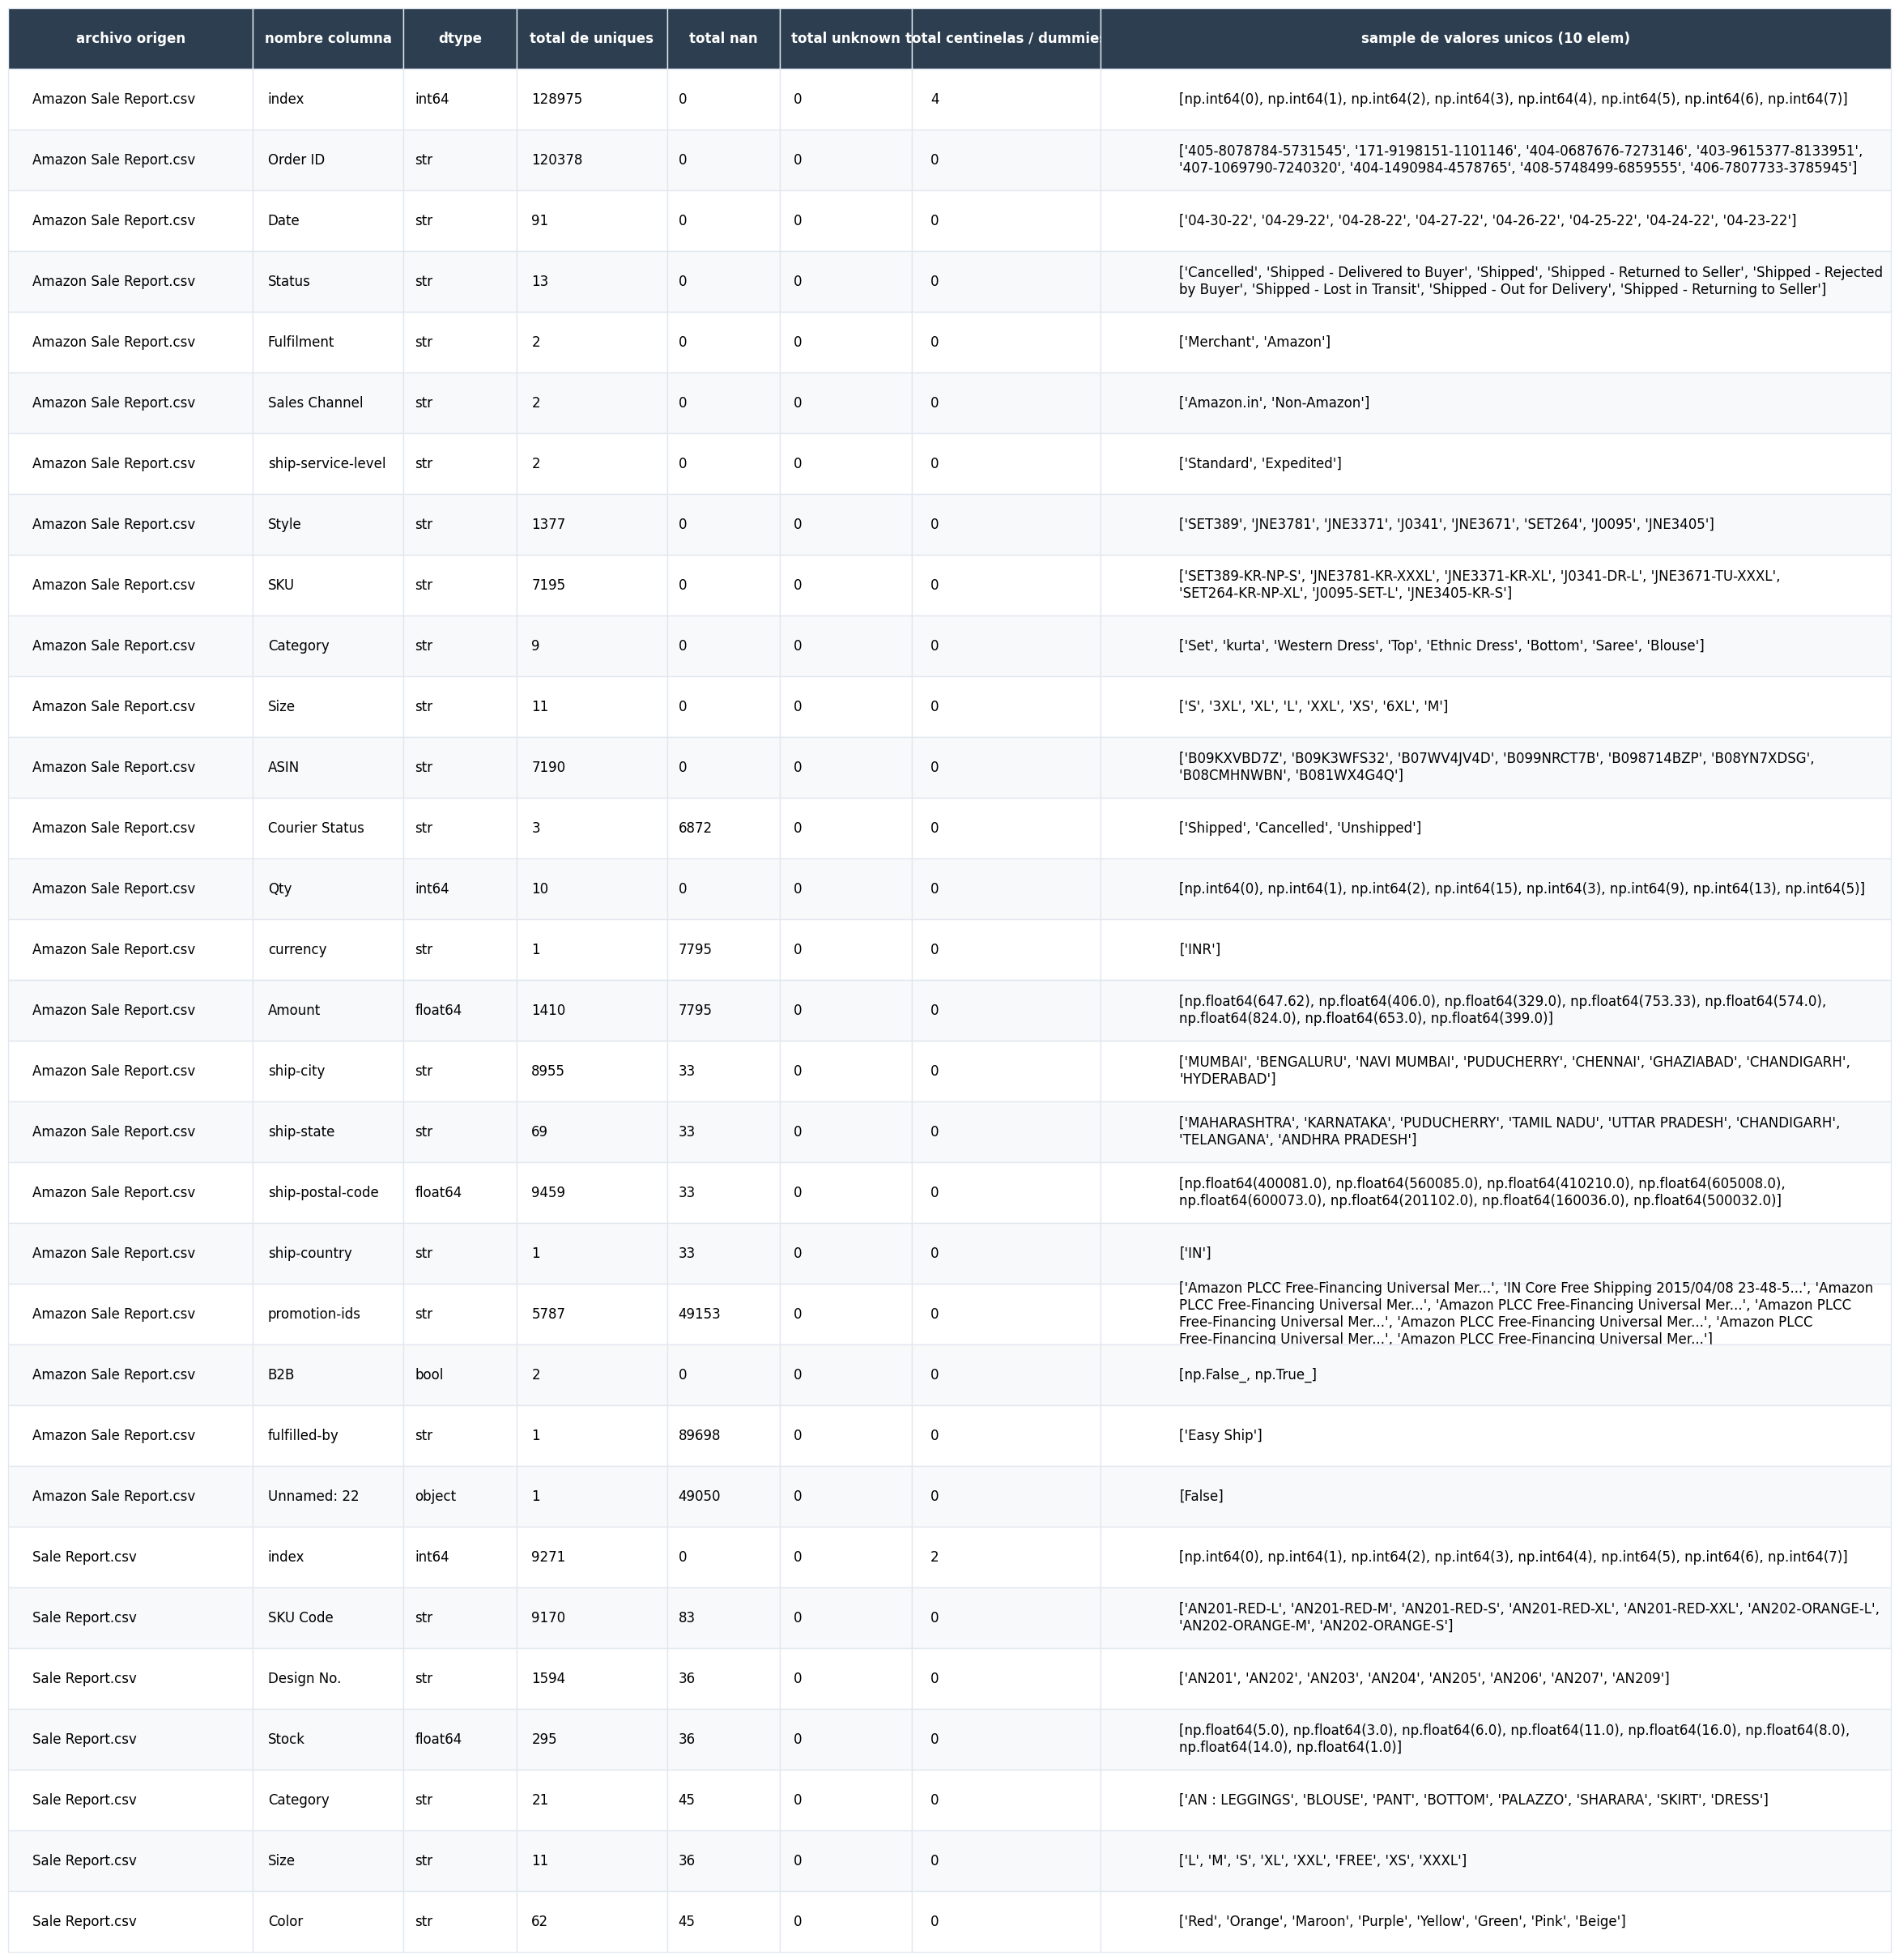

In [12]:
#guardamos el resultado como imagen PNG para incluirlo en el informe final (opcional, pero recomendado para la presentación visual)
# Para esto, necesitamos convertir el DataFrame estilizado a una imagen.
# Excluimos la opcion de la biblioteca 'dataframe_image' por dependencias complejas del chrome que pueden generar conflictor en entornos .venvs
# Convertir el DataFrame estilizado a imagen PNG

import matplotlib.pyplot as plt

# 1. Preparamos una copia optimizada exclusivamente para la preparar el gráfico.
df_plot = df_auditoria_calidad.copy()

# Aplanamos las listas de muestras a texto plano e higienizar nombres kilométricos
df_plot[df_plot.columns[-1]] = df_plot[df_plot.columns[-1]].astype(str)
# Anteponemos la 'r' para indicarle a Python que es un string en bruto (Raw String)
df_plot['archivo origen'] = df_plot['archivo origen'].str.replace(r' \(Transaccional\)', '', regex=True)
df_plot['archivo origen'] = df_plot['archivo origen'].str.replace(r' \(Maestro Catálogo\)', '', regex=True)

# 2. Creamos el lienzo para el gráfico con dimensiones de alta resolución
# Aumentamos ligeramente el tamaño horizontal (30x8) para que el texto ajustado respire
fig, ax = plt.subplots(figsize=(30, 8))
ax.axis('off')  # Desactivamos y ocultamos por completo los ejes cartesianos tradicionales

# CONTROL DE ANCHOS DE COLUMNA (Suman exactamente 1.0, cubriendo el 100% del lienzo)
# Mapeo: 0: Origen, 1: Columna, 2: Dtype, 3: Uniques, 4: NaN, 5: Unknown, 6: Sentinelas, 7: Muestras (Última)
# Optimizamos las columnas métricas (3 a 6) y le asignamos un ancho masivo a la última (columna 7 -> 0.36)
anchos_personalizados = [0.13, 0.08, 0.06, 0.08, 0.06, 0.07, 0.10, 0.42]

# 3. Construimos la estructura de la tabla pasando el parámetro colWidths
tabla_grafica = ax.table(
    cellText=df_plot.values,
    colLabels=df_plot.columns,
    cellLoc='left',
    loc='center',
    colWidths=anchos_personalizados  # Inyección de la matriz de anchos estricta
)

# 4. Configuramos la escala  y el tamaño de fuente.
tabla_grafica.auto_set_font_size(False)
tabla_grafica.set_fontsize(12)  # Bajamos a 12 para dar más margen al salto de línea
# Aumentamos la escala vertical a 2.3 para que las filas tengan suficiente altura 
# y el texto ajustado en múltiples líneas no se solape
tabla_grafica.scale(1.0, 4.5)  

# 5. Bucle : Colorear cabeceras, filas alternas y Ajustar Texto. 
for (fila, columna), celda in tabla_grafica.get_celld().items():
    
    # CONFIGURACIÓN : Forzamos el ajuste de texto (Word Wrap) según el ancho de celda
    celda.get_text().set_wrap(True)
    
    if fila == 0:
        # Estilo para la fila de títulos (Cabecera)
        celda.set_text_props(weight='bold', color='white')
        celda.set_facecolor('#2C3E50')  # Gris Pizarra Industrial
    else:
        # Alterna el fondo de las filas para mejorar la lectura de métricas
        if fila % 2 == 0:
            celda.set_facecolor('#F8F9FA')  # Gris tenue de contraste
            
    # Ajusta márgenes internos mínimos de las celdas
    celda.set_edgecolor('#E2E8F0')

# 6. Exportamos de forma automática usando la función creada arriba.
guardar_grafica("auditoria_calidad_datos_inicial.png")

# 7. Desplegamos el lienzo definitivo en la pantalla del cuaderno
plt.show()

In [13]:
print("🕵️‍♂️ --- EVIDENCIAS PARA LA LIMPIEZA BASE ---")

# Evidencia 1: El tipo de la columna temporal
tipo_fecha = df_amazon['Date'].dtype
print(f"1. Variable 'Date': Detectada como tipo '{tipo_fecha}'.")
print(f"   ⚠️ PROBLEMA: Es un string. No podemos hacer filtros temporales ni series continuas.")

# Evidencia 2: Inspección visual de la Join Key (SKU)
print(f"\n2. Muestra de la Llave Primaria 'SKU' en bruto:")
print(df_amazon['SKU'].head(3).tolist())
print(f"   ⚠️ RIESGO: Al provenir de archivos CSV independientes, los strings pueden contener espacios invisibles ")
print(f"   a los lados (ej. 'SKU-01 ' vs 'SKU-01'), lo que causaría que el JOIN ignore registros válidos.")

# Evidencia 3: Cardinalidad de variables cualitativas masivas
print(f"\n3. Análisis de repetición de textos en columnas cualitativas:")
print(f"   - Valores únicos en 'Status': {df_amazon['Status'].nunique()}")
print(f"   - Valores únicos en 'Fulfilment': {df_amazon['Fulfilment'].nunique()}")
print(f"   ⚠️ OPTIMIZACIÓN: Al tener tan pocos valores únicos repartidos en 128.000 filas,")
print(f"   guardarlos como texto estándar ('object') consume memoria RAM y tambien no permite\n   futuro análisis de correlación como 'categoria' y 'estado pedido' .")

🕵️‍♂️ --- EVIDENCIAS PARA LA LIMPIEZA BASE ---
1. Variable 'Date': Detectada como tipo 'str'.
   ⚠️ PROBLEMA: Es un string. No podemos hacer filtros temporales ni series continuas.

2. Muestra de la Llave Primaria 'SKU' en bruto:
['SET389-KR-NP-S', 'JNE3781-KR-XXXL', 'JNE3371-KR-XL']
   ⚠️ RIESGO: Al provenir de archivos CSV independientes, los strings pueden contener espacios invisibles 
   a los lados (ej. 'SKU-01 ' vs 'SKU-01'), lo que causaría que el JOIN ignore registros válidos.

3. Análisis de repetición de textos en columnas cualitativas:
   - Valores únicos en 'Status': 13
   - Valores únicos en 'Fulfilment': 2
   ⚠️ OPTIMIZACIÓN: Al tener tan pocos valores únicos repartidos en 128.000 filas,
   guardarlos como texto estándar ('object') consume memoria RAM y tambien no permite
   futuro análisis de correlación como 'categoria' y 'estado pedido' .


**4. Acciones 'Pre-join' I : Estandarización de la Llave para realizar el Join, Optimización de Memoria** 
- Limpieza base de Transacciones (df_amazon)
    * Limpiamos la Join Key (SKU): Quitamos espacios invisibles a los lados de los códigos de producto en ambos DataFrames para asegurar un cruce del 100% libre de fallos de caracteres.

    * Temporal: Pasamos la columna de fechas a tipo datetime64[ns] para poder explotar series temporales más adelante.

- Limpieza base de datos de Referencia (df_catalogo)
    * Limpiamos la Join Key (SKU Code)
    * Convertimos La columna 'SKU Code' a 'SKU'




In [14]:
print("⏳ Iniciando el proceso de limpieza básica pre-JOIN...")

# Medimos la memoria RAM inicial de la fuente principal (df_amazon) para tener 
# un punto de referencia antes de aplicar las transformaciones.
memoria_inicial_mb = df_amazon.memory_usage(deep=True).sum() / (1024 ** 2)


⏳ Iniciando el proceso de limpieza básica pre-JOIN...


In [15]:

print("⏳ Iniciando limpieza básica (df_amazon) pre-JOIN...")

# 
# FASE 1: Limpieza Básica (df_amazon)📠
# =====================================================================

# 1.1 Mantenemos una copia de variable 'Date' original
if 'Date_original' not in df_amazon.columns:
    df_amazon['Date_original'] = df_amazon['Date'].copy()

# 1.2 Limpiamos la columna temporal formato nativo indexable.
# 'format="mixed" simplifica la lectura de estructuras diferentes (guiones/barras)
# 'errors="coerce"' mitiga filas corruptas transformándolas en valores controlados NaT
df_amazon['Date'] = pd.to_datetime(df_amazon['Date'], errors='coerce', format='mixed')

# 1.3 Limpiamos la llave primaria eliminando espacios exteriores
df_amazon['SKU'] = df_amazon['SKU'].astype(str).str.strip()

# 1.4  Optimización para análisis y ahorro de memoria RAM:
#  Variables cualitativas a categorías lógicas (Arrays de NumPy)
columnas_categoricas = ['Status', 'Fulfilment', 'Category', 'Size', 'ship-state']
for col in columnas_categoricas:
    if col in df_amazon.columns:
        # Remover espacios en blanco antes de categorizar para evitar duplicidad oculta
        df_amazon[col] = df_amazon[col].str.strip()
        df_amazon[col] = df_amazon[col].astype('category')

print("✅ Fase 1 completada: df_amazon estandarizado, categorizado.")
# validamos que el cambio se haya aplicado correctamente

print("\n🔍 Validación de cambio a tipo 'category' en columnas cualitativas\n")
for col in columnas_categoricas:
    if col in df_amazon.columns:
        print(f"Columna '{col}': Tipo actual -> {df_amazon[col].dtype}")


⏳ Iniciando limpieza básica (df_amazon) pre-JOIN...
✅ Fase 1 completada: df_amazon estandarizado, categorizado.

🔍 Validación de cambio a tipo 'category' en columnas cualitativas

Columna 'Status': Tipo actual -> category
Columna 'Fulfilment': Tipo actual -> category
Columna 'Category': Tipo actual -> category
Columna 'Size': Tipo actual -> category
Columna 'ship-state': Tipo actual -> category


In [16]:

print(f"📅 Estado de la columna 'Date': Convertida con éxito a {df_amazon['Date'].dtype}.")
print(f"⚠️  Fechas anómalas o vacías convertidas a NaT de forma segura: {df_amazon['Date'].isna().sum()}")
print(f"Ejemplo de fechas después del formateo:")
print(f"{df_amazon['Date'].head()}")

📅 Estado de la columna 'Date': Convertida con éxito a datetime64[us].
⚠️  Fechas anómalas o vacías convertidas a NaT de forma segura: 0
Ejemplo de fechas después del formateo:
0   2022-04-30
1   2022-04-30
2   2022-04-30
3   2022-04-30
4   2022-04-30
Name: Date, dtype: datetime64[us]


In [17]:
#ejemplo de la columna 'Category' después de la conversión a 'category'
print("🎯 Catálogo oficial de categorías en la memoria de Pandas:")
print(df_amazon['Category'].cat.categories)

print("\n📊 Conteo unificado de productos (sin duplicados ocultos):")
print(df_amazon['Category'].value_counts())

🎯 Catálogo oficial de categorías en la memoria de Pandas:
Index(['Blouse', 'Bottom', 'Dupatta', 'Ethnic Dress', 'Saree', 'Set', 'Top',
       'Western Dress', 'kurta'],
      dtype='str')

📊 Conteo unificado de productos (sin duplicados ocultos):
Category
Set              50284
kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64


In [18]:

#  Calculamos balance final de memoria RAM después de las transformaciones para cuantificar
#  el impacto de la limpieza y optimización.
memoria_final_mb = df_amazon.memory_usage(deep=True).sum() / (1024 ** 2)
ahorro_porcentaje = ((memoria_inicial_mb - memoria_final_mb) / memoria_inicial_mb) * 100

print("\n✨ --- Reporte de  Limpieza Básica df_amazon---")
print(f"Integración: 'SKU Code' en Catálogo mapeado exitosamente a 'SKU'.")
print(f"Estado de las llaves: Ambas fuentes homogeneizadas y libres de espacios.")
print(f"Estado de la columna 'Date': Convertida con éxito a {df_amazon['Date'].dtype} (Sin Warnings).")
print(f"Fechas anómalas o vacías convertidas a NaT de forma segura: {df_amazon['Date'].isna().sum()}")
print(f"Eficiencia : Se ha liberado un {ahorro_porcentaje:.1f}% de memoria RAM en el Kernel.")



✨ --- Reporte de  Limpieza Básica df_amazon---
Integración: 'SKU Code' en Catálogo mapeado exitosamente a 'SKU'.
Estado de las llaves: Ambas fuentes homogeneizadas y libres de espacios.
Estado de la columna 'Date': Convertida con éxito a datetime64[us] (Sin Warnings).
Fechas anómalas o vacías convertidas a NaT de forma segura: 0
Eficiencia : Se ha liberado un 9.0% de memoria RAM en el Kernel.


In [19]:

#  FASE 2: Limpieza Básica (df_catalogo)📖
# ------------------------------------------------------------------------

# 2.1 Removemos espacios en blanco en la llave de catálogo original
df_catalogo['SKU Code'] = df_catalogo['SKU Code'].astype(str).str.strip()

# 2.2 Renombramos la columna como la 'key' común 'SKU'
df_catalogo = df_catalogo.rename(columns={'SKU Code': 'SKU'})

print("✅ Fase 2 completada: df_catalogo homogeneizado bajo la llave 'SKU'.")
print("\n🚀 El pipeline está ordenado y listo para iniciar la auditoría de duplicados.")


✅ Fase 2 completada: df_catalogo homogeneizado bajo la llave 'SKU'.

🚀 El pipeline está ordenado y listo para iniciar la auditoría de duplicados.


In [20]:
# Validamos que el cambio se haya aplicado correctamente
print("\n🔍 Validación del cambio de nombre de columna en df_catalogo:")
print(df_catalogo.columns.tolist())


🔍 Validación del cambio de nombre de columna en df_catalogo:
['index', 'SKU', 'Design No.', 'Stock', 'Category', 'Size', 'Color']


**5. Acciones Pre-Join II: Validación de Tasa de coincidencias entre los DataFrames (datasets) y 'Keys' únicos en df_catálogo**

Validamos la coincidencias entre ambos datasets para confirmar que el leftjoin es viable y no será un cúmulo de Nan. 

- Validación de intersecciones de los datasets, evaluación y acciones. 

- Validación de únicos en la 'key' de df_catalogo, evaluación y acciones. 


**5.1. Validación de Intersecciones de datasets**

In [21]:
# 1. Extraemos los conjuntos (Sets) de SKUs únicos de cada fuente
skus_ventas = set(df_amazon['SKU'].unique())
skus_catalogo = set(df_catalogo['SKU'].unique())

# 2. Calculamos las métricas de intersección y discrepancia (Operaciones de conjuntos)
skus_comunes = skus_ventas.intersection(skus_catalogo)
skus_huerfanos_ventas = skus_ventas.difference(skus_catalogo)

# 3. Calculamos la tasa de cobertura exacta
# ¿Cuántos de los registros de venta encontrarán su precio real en el catálogo?
ventas_con_match = df_amazon['SKU'].isin(skus_comunes).sum()
total_ventas = len(df_amazon)
match_rate_transaccional = (ventas_con_match / total_ventas) * 100

print("🔍 --- Auditoría de Intersección (PRE-JOIN) ---")
print(f"📦 SKUs únicos en el histórico de Ventas (Amazon): {len(skus_ventas):,}")
print(f"📖 SKUs únicos en el Catálogo Maestro: {len(skus_catalogo):,}")
print(f"🤝 SKUs idénticos encontrados en AMBAS fuentes (Intersección): {len(skus_comunes):,}")
print(f"⚠️  SKUs huérfanos (Existen en ventas df_amazon pero NO en catálogo): {len(skus_huerfanos_ventas):,}")
print(f"\n📈--- Cobertura del Pipeline:")
print(f"🧮 {ventas_con_match:,} de {total_ventas:,} transacciones encontrarán su stock.")
print(f"🎯 Tasa de Coincidencia (Match Rate): {match_rate_transaccional:.2f}%")

🔍 --- Auditoría de Intersección (PRE-JOIN) ---
📦 SKUs únicos en el histórico de Ventas (Amazon): 7,195
📖 SKUs únicos en el Catálogo Maestro: 9,171
🤝 SKUs idénticos encontrados en AMBAS fuentes (Intersección): 6,617
⚠️  SKUs huérfanos (Existen en ventas df_amazon pero NO en catálogo): 578

📈--- Cobertura del Pipeline:
🧮 121,269 de 128,975 transacciones encontrarán su stock.
🎯 Tasa de Coincidencia (Match Rate): 94.03%


**Acciones - tras evaluación intersección:**  
Ampliamos el scope, agregando el analisis de los elementos en el 'catálogo' que no tienen transacciones. 

*Auditoría de Stock Inmovilizado (Dead Stock) e Ineficiencia de Catálogo*

    Se expandió el alcance (*scope*) del proyecto de para identificar   SKUs que registran existencias físicas positivas en la base de datos de productos (`Stock > 0`), pero que presentan *ausencia de transacciones* en la plataforma de distribución de Amazon.  

    Esta métrica de control operativo aísla el inventario "muerto", permitiendo auditar costes ocultos de almacenamiento y detectar fallos potenciales de indexación digital de productos en el escaparate electrónico.

In [22]:

# 4. Ampliación del SCOPE: D.SKUs con Stock pero SIN VENTAS

# Línea base: Universo total de SKUs en catálogo que presentan CERO ventas vinculadas
skus_sin_ventas_total = skus_catalogo.difference(skus_ventas)

# Segmentación A: Cuantos de esos huérfanos tienen stock estrictamente mayor a cero (Dead Stock)
df_solo_catalogo = df_catalogo[df_catalogo['SKU'].isin(skus_sin_ventas_total)]
skus_muertos_con_stock = set(df_solo_catalogo[df_solo_catalogo['Stock'] > 0]['SKU'].unique())
total_unidades_inmovilizadas = df_solo_catalogo[df_solo_catalogo['SKU'].isin(skus_muertos_con_stock)]['Stock'].sum()

# Segmentación B: Cuantos de esos huérfanos tienen stock igual a cero (Líneas Obsoletas / Zombis)
skus_zombis_sin_stock = skus_sin_ventas_total.difference(skus_muertos_con_stock)

print("--- SCOPE D: AUDITORÍA DE PRODUCTOS SIN DEMANDA (LADO CATÁLOGO) ---\n\n")
print(f"📋 Total de SKUs huérfanos en df_catalogo (CERO Ventas en Amazon):  {len(skus_sin_ventas_total):,}")
print(f"   -> Con Stock mayor a cero (Inventario Inmovilizado / Dead Stock): {len(skus_muertos_con_stock):,}")
print(f"   -> Con Stock igual a cero (Líneas obsoletas o vacías):           {len(skus_zombis_sin_stock):,}")
print(f"🧮 Total de unidades físicas atrapadas acumulando polvo en almacén: {total_unidades_inmovilizadas:,.0f} unidades\n")

--- SCOPE D: AUDITORÍA DE PRODUCTOS SIN DEMANDA (LADO CATÁLOGO) ---


📋 Total de SKUs huérfanos en df_catalogo (CERO Ventas en Amazon):  2,554
   -> Con Stock mayor a cero (Inventario Inmovilizado / Dead Stock): 2,233
   -> Con Stock igual a cero (Líneas obsoletas o vacías):           321
🧮 Total de unidades físicas atrapadas acumulando polvo en almacén: 42,850 unidades



In [23]:
print("⚠️ --- Control: ventas sku's df_amazon & no están en catálogo ---")
print(f" - SKUs 'fantasma' vendidos en Amazon pero ausentes en catálogo:     {len(skus_huerfanos_ventas):,}")
print(f" - Impacto en transacciones afectadas:                             {total_ventas - ventas_con_match:,} filas.\n")

print("🧮 --- Validación de Totales  ---")
print(f" - SUMA CONTROL CATÁLOGO (Intersección {len(skus_comunes)} + Huérfanos {len(skus_sin_ventas_total)}): {len(skus_comunes) + len(skus_sin_ventas_total):,} (Debe dar 9,171)")
print(f" - SUMA CONTROL VENTAS    (Intersección {len(skus_comunes)} + Huérfanos {len(skus_huerfanos_ventas)}): {len(skus_comunes) + len(skus_huerfanos_ventas):,} (Debe dar 7,195)")

⚠️ --- Control: ventas sku's df_amazon & no están en catálogo ---
 - SKUs 'fantasma' vendidos en Amazon pero ausentes en catálogo:     578
 - Impacto en transacciones afectadas:                             7,706 filas.

🧮 --- Validación de Totales  ---
 - SUMA CONTROL CATÁLOGO (Intersección 6617 + Huérfanos 2554): 9,171 (Debe dar 9,171)
 - SUMA CONTROL VENTAS    (Intersección 6617 + Huérfanos 578): 7,195 (Debe dar 7,195)


**5.2. Auditoría por Etapas de diferencia únicos en 'SKU' df_catalogo**

Hay una diferencia entre el size del DataFrame y los 'unicos' en SKU:

In [24]:
print(f"df_catalogo: Total de filas: {len(df_catalogo):,} | SKUs únicos: {len(skus_catalogo):,}")
print(f"📖 SKUs únicos en el Catálogo Maestro: {len(skus_catalogo):,}")
print(f"📦 Total de SKUs en el Catálogo Maestro: {len(df_catalogo):,}")
print(f"Diferencia: {len(skus_catalogo) - len(df_catalogo):,} (Deben ser iguales, si no, hay duplicados ocultos en catálogo)")

df_catalogo: Total de filas: 9,271 | SKUs únicos: 9,171
📖 SKUs únicos en el Catálogo Maestro: 9,171
📦 Total de SKUs en el Catálogo Maestro: 9,271
Diferencia: -100 (Deben ser iguales, si no, hay duplicados ocultos en catálogo)


-🔍Hallazgos:
    El pipeline de limpieza básica ha estandarizado las fuentes y revelado una duplicidad de SKU's.

- Acciones -->
    A: Identificar y agrupar registros duplicados
    B. Validaciones para tomar decisiones sobre la limpieza de duplicados.

In [25]:

#A.Identificación y agrupación de registros duplicados
#Creamos el DataFrame espejo que contiene únicamente las filas cuyos SKUs aparecen más de una vez en el catálogo maestro.
print("📊 --- ETAPA A : Agrupación de registros repetidos  ---\n\n")

# 1. Filtrar el catálogo para aislar todas las filas con SKUs repetidos
df_duplicados_catalogo = df_catalogo[df_catalogo.duplicated(subset=['SKU'], keep=False)]
print("df_duplicados_catalogo: Filas del catálogo que presentan SKUs repetidos:")
display(df_duplicados_catalogo)
# 2. Calcular métricas base de volumen
total_filas_repetidas = len(df_duplicados_catalogo)
skus_unicos_repetidos = pd.DataFrame(df_duplicados_catalogo['SKU'].unique())


print("\n 💡Comprobamos que en la lista de repetidos se cuenta con SKU's con valor '#REF!' y con valor 'Nan'\n en la columna de SKU, lo que confirma que estos valores están contribuyendo a la duplicidad en el catálogo.\n\n")

print(f"Total de SKU's con #REF! en el catálogo: {len(df_catalogo[df_catalogo['SKU'] == '#REF!']):,}")
print(f"Total de SKU's con Nan en el catálogo: {len(df_catalogo[df_catalogo['SKU'].isnull()]):,}")
print(f"Total de SKU's con #REF! en df de repetidas: {len(df_duplicados_catalogo[df_duplicados_catalogo['SKU'] == '#REF!']):,}")
print(f"Total de SKU's con Nan en df de repetidas: {len(df_duplicados_catalogo[df_duplicados_catalogo['SKU'].isnull()]):,}")

print("\n\n 🚮 Validación de la contribución de '#REF!' y 'NaN' a la duplicidad y de totales para limpieza:\n\n ")

print(f"Número de filas con claves duplicadas en el catálogo: {total_filas_repetidas}")
print(f"Total de SKU's con #REF! en df de repetidas: {len(df_duplicados_catalogo[df_duplicados_catalogo['SKU'] == '#REF!']):,}")
print(f"Total de SKU's con Nan en el catálogo: {len(df_duplicados_catalogo[df_duplicados_catalogo['SKU'].isnull()]):,}")
print(f"Total de filas deSKUs (excluding #REF! and NaN): {df_duplicados_catalogo[(df_duplicados_catalogo['SKU'].notna()) &(df_duplicados_catalogo['SKU'] != '#REF!')].shape[0]}")
print(f"Cantidad de SKUs únicos afectados por esta duplicidad: {len(skus_unicos_repetidos)}")
display(skus_unicos_repetidos)


📊 --- ETAPA A : Agrupación de registros repetidos  ---


df_duplicados_catalogo: Filas del catálogo que presentan SKUs repetidos:


,index,SKU,Design No.,Stock,Category,Size,Color
65,65,#REF!,BL006,0.0,BLOUSE,FREE,Black
68,68,#REF!,BL008,0.0,BLOUSE,FREE,Red
73,73,#REF!,BL013,0.0,BLOUSE,FREE,Black
80,80,#REF!,BL019,0.0,BLOUSE,FREE,Pink
83,83,#REF!,BL021,0.0,BLOUSE,FREE,Black
...,...,...,...,...,...,...,...
9266,9266,NaN,NaN,NaN,NaN,NaN,NaN
9267,9267,NaN,NaN,NaN,NaN,NaN,NaN
9268,9268,NaN,NaN,NaN,NaN,NaN,NaN
9269,9269,NaN,NaN,NaN,NaN,NaN,NaN



 💡Comprobamos que en la lista de repetidos se cuenta con SKU's con valor '#REF!' y con valor 'Nan'
 en la columna de SKU, lo que confirma que estos valores están contribuyendo a la duplicidad en el catálogo.


Total de SKU's con #REF! en el catálogo: 15
Total de SKU's con Nan en el catálogo: 83
Total de SKU's con #REF! en df de repetidas: 15
Total de SKU's con Nan en df de repetidas: 83


 🚮 Validación de la contribución de '#REF!' y 'NaN' a la duplicidad y de totales para limpieza:

 
Número de filas con claves duplicadas en el catálogo: 106
Total de SKU's con #REF! en df de repetidas: 15
Total de SKU's con Nan en el catálogo: 83
Total de filas deSKUs (excluding #REF! and NaN): 8
Cantidad de SKUs únicos afectados por esta duplicidad: 6


,0
0,#REF!
1,NaN
2,PJNE3404-KR-4XL
3,PJNE3404-KR-5XL
4,PJNE3405-KR-5XL
5,PJNE3405-KR-6XL


In [26]:
#ETAPA B: Validaciones para tomar decisiones sobre la limpieza de duplicados

# B.Preparamos Mascaras para identificar SKUs legítimos vs. registros corruptos y comprobación de impacto.

# Preparamos las máscaras  basadas en la data excluyendo REF! y NaN para identificar los SKUs legítimos que se repiten
# Nota: Pandas lee '#REF!' y los nulos de distintas formas según el CSV, controlamos ambas
es_na = df_duplicados_catalogo['SKU'].isna() | (df_duplicados_catalogo['SKU'].astype(str).str.upper() == 'NAN')
es_ref = df_duplicados_catalogo['SKU'].astype(str).str.upper() == '#REF!'
es_valido = ~es_na & ~es_ref

print("📑B. Validaciones para tomar decisión sobre la limpieza de duplicados:\n\n")

# PREGUNTA 1: ¿Cuántos NaN tienen datos en el resto de columnas?
# =====================================================================
df_nan = df_duplicados_catalogo[es_na]
# Verificamos si al menos una de las columnas clave tiene datos (no es nula ni vacía)
columnas_clave = ['Design No.', 'Stock', 'Category', 'Size', 'Color']
filas_nan_con_datos = df_nan[columnas_clave].notna().any(axis=1).sum()

print(f"1. Filas donde el SKU es NaN pero contienen datos en otras columnas: {filas_nan_con_datos} de {len(df_nan)}")
display(df_nan.sample(min(5, len(df_nan))))  # Muestra aleatoria de hasta 5 filas para inspección visual

# PREGUNTA 2: ¿Qué hacemos con los 15 registros '#REF!'?
# --------------------------------------------------------------------------------
df_ref_con_stock = df_duplicados_catalogo[es_ref & (df_duplicados_catalogo['Stock'] > 0)]
print(f"2. Registros '#REF!' que tienen Stock físico > 0: {len(df_ref_con_stock)} de 15")
df_ref_sin_stock = df_duplicados_catalogo[es_ref & (df_duplicados_catalogo['Stock'] == 0)]
print(f"2. Registros '#REF!' que tienen Stock físico == 0: {len(df_ref_sin_stock)} de 15")

# PREGUNTA 3: Lista y repeticiones de los SKUs reales duplicados (ni NaN ni REF)
# --------------------------------------------------------------------------------
df_reales_duplicados = df_duplicados_catalogo[es_valido]
conteo_reales = df_reales_duplicados['SKU'].value_counts()
conteo_reales = conteo_reales[conteo_reales > 0] # Filtrar solo los presentes

print(f"3. Cantidad de SKUs legítimos duplicados ( excluyendo NaN y #REF!): {len(conteo_reales)}")
if len(conteo_reales) > 0:
    print("\n📋 Lista de SKUs reales repetidos y sus frecuencias:")
    print(conteo_reales.to_string())
else:
    print("   No hay SKUs reales duplicados fuera de NaN y #REF!")

#Pregunta 4 : ¿Cual es el impacto de los codigos SKU reales duplicados en el análisis 
# de ventas de Amazon (df_amazon)?
print(f"\n4. Impacto de los SKUs reales duplicados en el análisis de ventas de Amazon:💣")
# -------------------------------------------------------------------------------------------------------

#creamos una lista de los SKUs reales duplicados
skus_duplicados_reales =df_reales_duplicados['SKU'].unique()

#buscamos cuantos registros del df_amazon tienen SKUs que están en la lista de SKUs duplicados del catálogo
ventas_con_skus_duplicados = df_amazon[df_amazon['SKU'].isin(skus_duplicados_reales)]
print(f"\n ❕❕ Total de Transacciones en df_amazon que contienen SKUs duplicados del catálogo (excluyendo NaN y #REF!): {len(ventas_con_skus_duplicados)}")

📑B. Validaciones para tomar decisión sobre la limpieza de duplicados:


1. Filas donde el SKU es NaN pero contienen datos en otras columnas: 47 de 83


,index,SKU,Design No.,Stock,Category,Size,Color
1105,1105,NaN,J0096,0.0,KURTA,6XL,Blue
9248,9248,NaN,NaN,NaN,NaN,NaN,NaN
9246,9246,NaN,NaN,NaN,NaN,NaN,NaN
135,135,NaN,BL086,1.0,BLOUSE,FREE,Blue
7594,7594,NaN,SET111,0.0,NaN,XXXL,NaN


2. Registros '#REF!' que tienen Stock físico > 0: 1 de 15
2. Registros '#REF!' que tienen Stock físico == 0: 14 de 15
3. Cantidad de SKUs legítimos duplicados ( excluyendo NaN y #REF!): 4

📋 Lista de SKUs reales repetidos y sus frecuencias:
SKU
PJNE3404-KR-4XL    2
PJNE3404-KR-5XL    2
PJNE3405-KR-5XL    2
PJNE3405-KR-6XL    2

4. Impacto de los SKUs reales duplicados en el análisis de ventas de Amazon:💣

 ❕❕ Total de Transacciones en df_amazon que contienen SKUs duplicados del catálogo (excluyendo NaN y #REF!): 0


#### 💡 *Conclusión de duplicados*:💡  ####

De las miles de líneas del proyecto, el problema real se reduce:
- Resumen de totales: 
    * 9271 registros
    * 9171 únicos ( incluidos Nan y #REF! )
    * 100 registros de diferencia
    
    * 15 registros con '#REF'
    * 83 registros con Nan

    * 6 Valores únicos en los 100 valores duplicados ( incluidos Nan y #REF! )

- a 1 solo registro con stock en #REF! con stock. Como solo una fila tiene stock (y de apenas unas pocas unidades), el impacto logístico es irrelevante. Al no tener un SKU válido, es técnicamente imposible cruzarlo con las ventas de Amazon. Se descarta del catálogo.

- exactamente 4 SKUs legítimos duplicados (que se repiten solo 2 veces cada uno).Tienen exactamente 2 filas cada uno (8 filas en total). Al revisar tu muestra visual previa (con el caso del PJNE3404-KR-4XL), descubrimos que la duplicidad ocurre porque una fila tiene el color Mauve con stock y la otra el color Wine con stock 0. 
Si hacemos el LEFT JOIN directamente, estas 8 filas provocaría un problema en el Join, " duplicando transacciones de venta.

Con este volumen pequeño,lo resolveremos con un criterio de limpieza. 

In [27]:
print("🧹 Iniciando limpieza selectiva y consolidación de inventario...")

# 1. Creamos la copia explícita de trabajo para proteger la fuente primaria
df_catalogo_clean = df_catalogo.copy()

# 2. Filtramos quirúrgico: Eliminar filas donde el SKU sea nulo (NaN) o el artefacto '#REF!'
# Al guardarlos en una máscara, el recolector de basura de Python libera la RAM de esas filas
es_invalido = (
    df_catalogo_clean['SKU'].isna() | 
    (df_catalogo_clean['SKU'].astype(str).str.strip().str.upper() == 'NAN') | 
    (df_catalogo_clean['SKU'].astype(str).str.strip().str.upper() == '#REF!')
)
df_catalogo_clean = df_catalogo_clean[~es_invalido]
print(f"✅ Filtrado aplicado: Se han eliminado filas con SKU inválidos (NaN y '#REF!').")
print(f"Filas restantes después de la limpieza: {len(df_catalogo_clean):,}")
print(f"📉 Reducción de filas: {len(df_catalogo) - len(df_catalogo_clean):,} filas eliminadas.")


🧹 Iniciando limpieza selectiva y consolidación de inventario...
✅ Filtrado aplicado: Se han eliminado filas con SKU inválidos (NaN y '#REF!').
Filas restantes después de la limpieza: 9,173
📉 Reducción de filas: 98 filas eliminadas.


In [28]:

# 3. Consolidamos el stock (Evita la pérdida de stock sumando los duplicados)
# Agrupamos por SKU: sumamos la columna numéricas 'Stock' y tomamos el primer registro de las cualitativas
# Usamos groupby con as_index=False para mantener la columna 'SKU' como parte del DataFrame resultante
# La función .agg() nos permite aplicar diferentes operaciones a cada columna:
df_catalogo_clean = df_catalogo_clean.groupby('SKU', as_index=False).agg({
    'index': 'first',       # Preservamos el índice de la primera aparición del SKU
    'Design No.': 'first',
    'Stock': 'sum',         #SUMA TOTAL: Asegura no destruir unidades físicas del almacén
    'Category': 'first',
    'Size': 'first',
    'Color': 'first'})
print("✅ Filtrado 2 aplicado: Se han agrupado filas con SKU válidos pero repetidos(first row & sum stock).")
print(f"Filas restantes después de la limpieza: {len(df_catalogo_clean):,}")

✅ Filtrado 2 aplicado: Se han agrupado filas con SKU válidos pero repetidos(first row & sum stock).
Filas restantes después de la limpieza: 9,169


**Validación : tenemos 9169 vs 9171 registros únicos , perdiendo 2 lineas de registros debido a Nan y '#REF!'.**

In [29]:

# 4. Restauramos el Orden y reseateamos el índice de Pandas para que sea continuo (0, 1, 2...)

# Volvemos al orden posicional que tenía el CSV original usando la columna de referencia
df_catalogo_clean = df_catalogo_clean.sort_values(by='index')

# Reseteamos el índice de Pandas para que sea continuo (0, 1, 2...) eliminando saltos estructurales
df_catalogo_clean = df_catalogo_clean.reset_index(drop=True)

print(f"✨ Proceso completado exitosamente.")
print(f"📦 Dimensiones finales de 'df_catalogo_clean' (Único y Reconciliado): {df_catalogo_clean.shape}")


✨ Proceso completado exitosamente.
📦 Dimensiones finales de 'df_catalogo_clean' (Único y Reconciliado): (9169, 7)



📝**Reglas aplicadas para la eliminación de duplicados del catálogo:**  

- Se excluyen los registros sin clave indexable (NaN, #REF!).  
- Se consolidan los duplicados con valores 'SKu' válidos realizando una agrupación con método groupby().agg(),sumando el 'Stock' para reducir la pérdida de existencias.  
- Finalmente, se restaura la secuencia de origen mediante el ordenamiento del 'index' inicial.


**6. Join de los conjuntos de datos y primeros insights**

Se opta por un LEFT JOIN con :  
df_amazon: 128975 | Columnas: 24
df_catalogo_clean: 9169 | Columnas: 2 de 7 ( SKU, STOCK)

In [30]:
# 1. Unificamos las fuentes mediante un LEFT JOIN  por la llave común 'SKU'
# Fusionamos la matriz transaccional masiva con la dimensión depurada de inventario físico
df_initial_amazon_stock = pd.merge(df_amazon, df_catalogo_clean[['SKU', 'Stock']], on='SKU', how='left')
print("⏳ Ejecutando la fusión (LEFT JOIN Inventario)...")

⏳ Ejecutando la fusión (LEFT JOIN Inventario)...


In [31]:

# 2. Extraemos las dimensiones finales del dataset unificado para validar contra los requisitos mínimos del proyecto.
filas, columnas = df_initial_amazon_stock.shape

print("\n🎯 --- AUDITORÍA DE REQUISITOS MÍNIMOS ---")
print(f"Volumen de transacciones logradas (Filas): {filas:,} (Exigido: >50,000)")
print(f"Extensión del modelo unificado (Columnas): {columnas} (Exigido: >20)")



🎯 --- AUDITORÍA DE REQUISITOS MÍNIMOS ---
Volumen de transacciones logradas (Filas): 128,975 (Exigido: >50,000)
Extensión del modelo unificado (Columnas): 26 (Exigido: >20)


In [32]:

# 3. Mapeamos el volumen de registros que van a requerir limpieza en el Bloque 14
nulos_stock_post_join = df_initial_amazon_stock['Stock'].isna().sum()
print(f" Transacciones asociadas a SKUs huérfanos (Stock convertido a NaN): {nulos_stock_post_join:,} filas.")
print(f" Tasa de registros afectados por SKUs huérfanos: {(nulos_stock_post_join / filas) * 100:.2f}%")


 Transacciones asociadas a SKUs huérfanos (Stock convertido a NaN): 7,706 filas.
 Tasa de registros afectados por SKUs huérfanos: 5.97%


In [33]:

# 4. Validamos la integridad estructural de la entrega frente a los mínimos normativos
if filas >= 50000 and columnas >= 20:
    print("\n ¡ ÉXITO! El dataset unificado 'df_initial_amazon_stock' cumple con las dimensiones.")
else:
    print("\n ALERTA ESTRUCTURAL: Las dimensiones del cruce no alcanzan los mínimos exigidos.")


 ¡ ÉXITO! El dataset unificado 'df_initial_amazon_stock' cumple con las dimensiones.


In [34]:
# 5. Exportamos el dataset unificado pre-limpieza para su análisis y referencia futura

print("⏳ Iniciando la exportación de la capa intermedia RAW...")

# 5.1. Creamos la ruta o carpeta de destino para almacenar los archivos procesados
os.makedirs('data_intermedia', exist_ok=True)


⏳ Iniciando la exportación de la capa intermedia RAW...


In [35]:

# 5.2. Exportamos el DataFrame unificado en formato CSV para inspección visual directa

# 1. Definimos el directorio apuntando a la estructura estándar de datos
directorio_salida_raw = '../data/raw'
os.makedirs(directorio_salida_raw, exist_ok=True)

ruta_csv_raw = f'{directorio_salida_raw}/df_initial_amazon_stock_RAW.csv'
df_initial_amazon_stock.to_csv(ruta_csv_raw, index=False, encoding='utf-8')

print(f"Archivo CSV RAW guardado en: {ruta_csv_raw}")

Archivo CSV RAW guardado en: ../data/raw/df_initial_amazon_stock_RAW.csv


In [36]:
!pip install pyarrow


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
# 3. Exportamos también en formato Parquet para preservar tipos de datos
ruta_parquet_raw = f'{directorio_salida_raw}/df_initial_amazon_stock_RAW.parquet'
df_initial_amazon_stock.to_parquet(ruta_parquet_raw, index=False)
print(f"Archivo Parquet RAW guardado en: {ruta_parquet_raw}")

Archivo Parquet RAW guardado en: ../data/raw/df_initial_amazon_stock_RAW.parquet


In [38]:

print("\n💾 --- REPORTE DE EXPORTACIÓN CAPA INTERMEDIA ---")
print(f"📊 Volumen total de registros congelados en bruto: {len(df_initial_amazon_stock):,} filas.")



💾 --- REPORTE DE EXPORTACIÓN CAPA INTERMEDIA ---
📊 Volumen total de registros congelados en bruto: 128,975 filas.


**6. Limpieza de Dataframe para análisis final.**

In [39]:
#Creamos una copia de trabajo para aplicar la limpieza sin afectar el dataset original
df_amazonstock_toclean = df_initial_amazon_stock.copy()

**6.A. Auditoría  y Comprobación de Hipótesis**

*1.RESUMEN DE COLUMNAS EXCLUSIVAS CON ANOMALÍAS (NaNs o Dummies)*


In [40]:
print("⏳ A. Iniciamos la Auditoría y Comprobación de Hipótesis...")

# 1.RESUMEN DE COLUMNAS EXCLUSIVAS CON ANOMALÍAS (NaNs o Dummies)
# -------------------------------------------------------------------
# Calculamos los nulos sobre el dataset RAW para ver la realidad original
nulos_totales = df_amazonstock_toclean.isna().sum()
columnas_con_nulos = nulos_totales[nulos_totales > 0]

print("\n📊 --- RESUMEN DE COLUMNAS CON VALORES AUSENTES (TARGET DE LIMPIEZA) ---")
for col, faltantes in columnas_con_nulos.items():
    porcentaje = (faltantes / len(df_amazonstock_toclean)) * 100
    print(f"🔹 {col}: {faltantes:,} nulos ({porcentaje:.2f}%)")


⏳ A. Iniciamos la Auditoría y Comprobación de Hipótesis...

📊 --- RESUMEN DE COLUMNAS CON VALORES AUSENTES (TARGET DE LIMPIEZA) ---
🔹 Courier Status: 6,872 nulos (5.33%)
🔹 currency: 7,795 nulos (6.04%)
🔹 Amount: 7,795 nulos (6.04%)
🔹 ship-city: 33 nulos (0.03%)
🔹 ship-state: 33 nulos (0.03%)
🔹 ship-postal-code: 33 nulos (0.03%)
🔹 ship-country: 33 nulos (0.03%)
🔹 promotion-ids: 49,153 nulos (38.11%)
🔹 fulfilled-by: 89,698 nulos (69.55%)
🔹 Unnamed: 22: 49,050 nulos (38.03%)
🔹 Stock: 7,706 nulos (5.97%)


*2.COMPROBACIÓN DE HIPÓTESIS Y EXTRACCIÓN DE MUESTRAS* 


In [41]:


# 2. COMPROBACIÓN DE HIPÓTESIS Y EXTRACCIÓN DE MUESTRAS
# -------------------------------------------------------------------
print("\n🔬 --- COMPROBACIÓN DE HIPÓTESIS RELACIONALES ---")

# Hipótesis A: ¿Los nulos en 'Courier Status' coinciden con los nulos de 'Amount'?
# Cruzamos ambas variables para ver cuántas veces el importe es nulo cuando el mensajero no tiene estado
filtro_courier_nulo = df_amazonstock_toclean['Courier Status'].isna()
cantidad_courier_nulo = filtro_courier_nulo.sum()
coincidencia_amount_nulo = df_amazonstock_toclean[filtro_courier_nulo]['Amount'].isna().sum()

tasa_coincidencia = (coincidencia_amount_nulo / cantidad_courier_nulo) * 100 if cantidad_courier_nulo > 0 else 0

print(f"Hipótesis A (Courier vs Amount):")
print(f"  ➡️ Registros sin 'Courier Status': {cantidad_courier_nulo:,}")
print(f"  ➡️ De esos, registros que TAMBIÉN tienen 'Amount' en nulo: {coincidencia_amount_nulo:,} ({tasa_coincidencia:.1f}%)")



🔬 --- COMPROBACIÓN DE HIPÓTESIS RELACIONALES ---
Hipótesis A (Courier vs Amount):
  ➡️ Registros sin 'Courier Status': 6,872
  ➡️ De esos, registros que TAMBIÉN tienen 'Amount' en nulo: 1,736 (25.3%)


In [42]:

# HIPOTESIS B: Entender la anatomía de la columna 'fulfilled-by' (~89k nulos)
print("\n📋 Hipótesis B (Muestreo de 'fulfilled-by'):")
# Extraemos los valores únicos de la columna para entender qué datos contiene cuando NO es nula
valores_fulfilled = df_amazonstock_toclean['fulfilled-by'].dropna().unique()
print(f"  ➡️ Valores registrados cuando la columna tiene datos: {valores_fulfilled}")

# Comparamos quién despacha (Fulfilment) cuando 'fulfilled-by' es nula vs cuando tiene datos
print("  ➡️ ¿Quién despacha el pedido cuando 'fulfilled-by' es NULO?")
print(df_amazonstock_toclean[df_amazonstock_toclean['fulfilled-by'].isna()]['Fulfilment'].value_counts())

print("  ➡️ ¿Quién despacha el pedido cuando 'fulfilled-by' TIENE DATOS?")
print(df_amazonstock_toclean[df_amazonstock_toclean['fulfilled-by'].notna()]['Fulfilment'].value_counts())


📋 Hipótesis B (Muestreo de 'fulfilled-by'):
  ➡️ Valores registrados cuando la columna tiene datos: <ArrowStringArray>
['Easy Ship']
Length: 1, dtype: str
  ➡️ ¿Quién despacha el pedido cuando 'fulfilled-by' es NULO?
Fulfilment
Amazon      89698
Merchant        0
Name: count, dtype: int64
  ➡️ ¿Quién despacha el pedido cuando 'fulfilled-by' TIENE DATOS?
Fulfilment
Merchant    39277
Amazon          0
Name: count, dtype: int64


3. 🔬 Interpretación de los Resultados:
-----------------------------------------------------------
* 6.A.1. Refutamos de la Hipótesis A (Courier Status vs Amount):
Solo el 25.3% de los pedidos sin estado de mensajería están cancelados/sin importe.  
Esto significa que el 75% de los pedidos sin Courier Status SÍ tienen Amount (el cliente pagó).
La alternativa de borrado esas filas asumiendo que eran cancelaciones,hubiese eliminado en ingresos legítimos.

    ♟ Estrategia: Imputaremos los nulos de Courier Status con la etiqueta 'Unknown' (Desconocido) para preservar intacta la información financiera de esas filas.
    Dejaremos Nan en 'Amount' para conservar la integridad de las operaciones posteriores y cálculos de medias que se podrñian ver afectadas si se completan 

* 6.A.2. Confirmamos de la Hipótesis B (fulfilled-by):
Hay una correlación del 100%: cuando el vendedor despacha el pedido (Merchant), la columna fulfilled-by marca 'Easy Ship'. Cuando lo despacha Amazon, la columna simplemente se queda vacía.

    ♟Estrategia: Rellenaremos los 89,698 nulos de fulfilled-by con el valor explícito 'Amazon'.

* 6.A.3. Limpieza de Otras Columnas :

* Columna 'Trash' (Unnamed: 22):
Es un un error de delimitación de comas al exportar el CSV desde el sistema original. No aporta valor.

    ♟ Estrategia: Eliminaciónde la columna (Drop).

* Ausencia de Promociones (promotion-ids):
Un nulo aquí no es un error de sistema, simplemente significa que el cliente compró sin usar un cupón de descuento.

    ♟ Estrategia: Imputaremos los nulos con 'No Promotion'.

* Geografía (33 nulos):
Siendo solo el 0.03%, podríamos borrarlos, pero para no perder el importe de esas 33 ventas, los etiquetaremos como desconocidos.

    ♟ Estrategia: Imputaremos con 'UNKNOWN'.

**6.B. Limpieza por bloques.**

In [43]:
print("⏳ Ejecutamos pipeline de limpieza conservando la estructura")

# 0. PRESERVACIÓN DE DATOS ORIGEN (COLUMNAS RAW)
# Creamos copias exactas de las columnas objetivo antes de alterarlas para mantener la trazabilidad
columnas_a_limpiar = [
    'fulfilled-by', 'Courier Status', 'promotion-ids', 'currency', 
    'ship-city', 'ship-state', 'ship-postal-code', 'ship-country'
]

for col in columnas_a_limpiar:
    df_amazonstock_toclean[f"{col}_raw"] = df_amazonstock_toclean[col]

print(f"🔒 Trazabilidad asegurada: Se han creado {len(columnas_a_limpiar)} columnas '_raw' como respaldo para auditoría.")
print(f"Lista de las columnas del dataframe:{df_amazonstock_toclean.columns.tolist()}")

⏳ Ejecutamos pipeline de limpieza conservando la estructura
🔒 Trazabilidad asegurada: Se han creado 8 columnas '_raw' como respaldo para auditoría.
Lista de las columnas del dataframe:['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22', 'Date_original', 'Stock', 'fulfilled-by_raw', 'Courier Status_raw', 'promotion-ids_raw', 'currency_raw', 'ship-city_raw', 'ship-state_raw', 'ship-postal-code_raw', 'ship-country_raw']


In [44]:

# 1. DOMINIO OPERACIONAL Y LOGÍSTICO
# Hipótesis B confirmada: Los nulos corresponden a despachos gestionados por Amazon
df_amazonstock_toclean['fulfilled-by'] = df_amazonstock_toclean['fulfilled-by'].fillna('Amazon')

# Hipótesis A refutada: Preservamos el Courier Status como 'Unknown' para no destruir ventas pagadas
df_amazonstock_toclean['Courier Status'] = df_amazonstock_toclean['Courier Status'].fillna('Unknown')

# Un nulo en promoción representa una venta ordinaria sin cupón aplicado
df_amazonstock_toclean['promotion-ids'] = df_amazonstock_toclean['promotion-ids'].fillna('No Promotion')


In [ ]:

# 2. DOMINIO FINANCIERO (Residual)
# Si no hay moneda registrada, aplicamos la divisa base del mercado indio (INR)
df_amazonstock_toclean['currency'] = df_amazonstock_toclean['currency'].fillna('INR')

#'Amount' mantenemos los Nan en esta columna para evitar medias, promedios, en otros 
# cálculos que se vean alterados si reemplazamos por cero.


In [72]:
# 3. DOMINIO GEOGRÁFICO (Optimizado)
#Abordamos la limpieza de  Nan, nan, etc
columnas_geograficas = ['ship-city', 'ship-state', 'ship-postal-code', 'ship-country']

for col in columnas_geograficas:
    # 💡 JUSTIFICACIÓN ARQUITECTÓNICA DE REVERSIÓN DE TIPO:
    # Las columnas geográficas poseen "Alta Cardinalidad" (miles de valores únicos diferentes).
    # Mantenerlas bajo el tipo 'category'  satura el diccionario interno de Pandas,
    # ralentiza el procesamiento y bloquea la imputación de nuevas etiquetas (lanzando TypeError).
    # Revertimos explícitamente a texto plano (str) para optimizar el motor y permitir la limpieza.
    df_amazonstock_toclean[col] = df_amazonstock_toclean[col].astype(str)
    
    # Tras la conversión, los nulos de sistema (NaN) pueden mutar al texto literal 'nan'.
    # Construimos una máscara booleana  para capturar ambas naturalezas e imputar la etiqueta de control.
    es_nulo_geografico = df_amazonstock_toclean[col].isna() | (df_amazonstock_toclean[col].str.strip().str.lower() == 'nan')
    df_amazonstock_toclean.loc[es_nulo_geografico, col] = 'UNKNOWN'

# Al existir muchas ciudades, decidimos abordar la limpieza y normalizar la columna de 'ship-state' que nos permitirá
#  realizar cualquier analisis geográfico requerido.

#  Lista OFICIAL de estados y territorios de la unión de la India
# 3.C.1. Lista OFICIAL modificada para separar entidades geográficas
estados_oficiales_IN = [
    "Andhra Pradesh", "Arunachal Pradesh", "Assam", "Bihar", "Chhattisgarh",
    "Goa", "Gujarat", "Haryana", "Himachal Pradesh", "Jharkhand", "Karnataka",
    "Kerala", "Madhya Pradesh", "Maharashtra", "Manipur", "Meghalaya", "Mizoram",
    "Nagaland", "Odisha", "Punjab", "Rajasthan", "Sikkim", "Tamil Nadu",
    "Telangana", "Tripura", "Uttar Pradesh", "Uttarakhand", "West Bengal",
    "Andaman and Nicobar Islands", "Chandigarh", "Delhi", "Jammu and Kashmir", 
    "Ladakh", "Lakshadweep", "Puducherry",
    # 📌 SEPARACIÓN GEOGRÁFICA CRÍTICA:
    "Dadra and Nagar Haveli", 
    "Daman and Diu"
]


In [75]:
#3.A Creamos DF con los estados unicos en su estado actual 

# 3.A.1. Obtenemos valores únicos actuales
estados_unicos = sorted(df_amazonstock_toclean['ship-state'].unique())

# 3.A.2. Creamos DataFrame de mapeo
df_mapeo_estados = pd.DataFrame(estados_unicos, columns=['Original'])

# 3.A.3. Aplicamos normalización de formato (Limpieza de espacios y capitalización)
# Esto resuelve automáticamente diferencias de mayúsculas/minúsculas (ej. delhi -> Delhi)
df_mapeo_estados['Corregido_Base'] = df_mapeo_estados['Original'].astype(str).str.strip().str.title()

# 3.A.4. Filtramos: Nos quedamos con los que cambian por formato (.title()) 
# O con aquellos que NO pertenecen a la lista oficial de estados (así atrapamos 'New Delhi', 'Pondicherry' o 'Punjab/Mohali/Zirakpur')
condicion_formato = df_mapeo_estados['Original'] != df_mapeo_estados['Corregido_Base']
condicion_no_oficial = ~df_mapeo_estados['Corregido_Base'].isin(estados_oficiales_IN)

df_revision = df_mapeo_estados[condicion_formato | condicion_no_oficial].copy()

# 3.A.5. Ordenamos para ver agrupados los estados por nombre
df_revision = df_revision.sort_values('Corregido_Base')

# 3.A.6. Vista completa sin truncar filas
print(f"🔍 Registros que requieren intervención manual ({len(df_revision)} en total):")
with pd.option_context('display.max_rows', None):
    display(df_revision)


🔍 Registros que requieren intervención manual (11 en total):


,Original,Corregido_Base
1,Andaman and Nicobar Islands,Andaman And Nicobar Islands
0,APO Army Post Office,Apo Army Post Office
8,Dadra and Nagar Haveli,Dadra And Nagar Haveli
14,Jammu and Kashmir,Jammu And Kashmir
26,New Delhi,New Delhi
28,Orissa,Orissa
29,Pondicherry,Pondicherry
32,Punjab/Mohali/Zirakpur,Punjab/Mohali/Zirakpur
34,Rajshthan,Rajshthan
35,Rajsthan,Rajsthan


In [76]:

# 3.B. Exportación para evaluar la información vs la data de internet sobre los estados de la India.

# 3.B.1. Definimos la ruta de destino
ruta_reportes = os.path.join('..', 'reports')
# 3.B.2. Guardamos el archivo en la ruta destino
cwd = os.getcwd()
print(f"Estás trabajando en: {cwd}")
ruta_completa = os.path.join(ruta_reportes, 'estados_a_corregir.csv')
df_revision.to_csv(ruta_completa, index=False)
print("\n✅ Archivo 'estados_a_corregir.csv' guardado.")


Estás trabajando en: c:\Users\jovic\JCProjectsDA\JC_EDA_ProyectoFinal\proyecto-final-analytics\notebooks

✅ Archivo 'estados_a_corregir.csv' guardado.


In [67]:
#importamos librería de Python que ayuda en estos casos. 
import difflib

In [ ]:
#3.C. Corrección de estados

# 3.C.2. Mapeos manuales críticos
# (Abreviaturas, nombres muy antiguos o casos especiales que el algoritmo no debe adivinar)
# Modificamos : 'Dadra And Nagar': 'Dadra and Nagar Haveli and Daman and Diu'  por dos lugares por encontrarse separados. 
#'Dadra And Nagar':'Dadra and Nagar Haveli'; 'Daman and Diu':'Daman and Diu', 
mapeos_manuales = {
    'Andaman & Nicobar': 'Andaman and Nicobar Islands',
    'Ar': 'Arunachal Pradesh',
    'Dadra And Nagar': 'Dadra and Nagar Haveli',
    'Dadra and Nagar Haveli':'Dadra and Nagar Haveli',	
    'Daman': 'Daman and Diu',
    'Jammu & Kashmir': 'Jammu and Kashmir',
    'Nl': 'Nagaland',
    'Orissa': 'Odisha',
    'Pb': 'Punjab',
    'Rj': 'Rajasthan',
    'Apo': 'APO Army Post Office',
    'Unknown': 'Unknown',
    'New Delhi': 'Delhi',
    # NUEVOS CASOS ASEGURADOS:
    'Punjab/Mohali/Zirakpur': 'Punjab',
    'Pondicherry': 'Puducherry'
}

# 3.C.3. Motor de resolución (aplicamos difflib para corregir typos automáticamente)
def resolver_estado(nombre_base):
    if nombre_base in mapeos_manuales:
        return mapeos_manuales[nombre_base]
    
    coincidencias = difflib.get_close_matches(nombre_base, estados_oficiales_IN, n=1, cutoff=0.6)
    
    if coincidencias:
        return coincidencias[0]
    else:
        return nombre_base


In [78]:

# 3.C.4. Aplicamos la función creando nueva columna y usando el método apply. 
df_revision['Corregido_final'] = df_revision['Corregido_Base'].apply(resolver_estado)

display(df_revision)

,Original,Corregido_Base,Corregido_final
1,Andaman and Nicobar Islands,Andaman And Nicobar Islands,Andaman and Nicobar Islands
0,APO Army Post Office,Apo Army Post Office,Apo Army Post Office
8,Dadra and Nagar Haveli,Dadra And Nagar Haveli,Dadra and Nagar Haveli
14,Jammu and Kashmir,Jammu And Kashmir,Jammu and Kashmir
26,New Delhi,New Delhi,Delhi
28,Orissa,Orissa,Odisha
29,Pondicherry,Pondicherry,Puducherry
32,Punjab/Mohali/Zirakpur,Punjab/Mohali/Zirakpur,Punjab
34,Rajshthan,Rajshthan,Rajasthan
35,Rajsthan,Rajsthan,Rajasthan


In [79]:
# 3.D.--- REEMPLAZO FINAL EN EL DOMINIO GEOGRÁFICO---

# 1. Convertimos nuestro df_revision en un diccionario súper rápido de Python
# Clave: Nombre Original con errores -> Valor: Nombre Oficial Corregido
mapa_estados = dict(zip(df_revision['Original'], df_revision['Corregido_final']))

# 2. Inyectamos el reemplazo directamente en la columna de la base de datos
df_amazonstock_toclean['ship-state'] = df_amazonstock_toclean['ship-state'].replace(mapa_estados)

# 3. Verificamos el impacto de nuestra limpieza
estados_finales = df_amazonstock_toclean['ship-state'].nunique()
print("✅ ¡Limpieza geográfica completada con éxito!")
print(f"📉 Redujimos el ruido: Ahora tenemos exactamente {estados_finales} estados consolidados.")

# 4. Comprobación visual (mostramos los primeros 15 ordenados alfabéticamente)
print("\nVista previa de la columna 'ship-state' limpio:")
print(sorted(df_amazonstock_toclean['ship-state'].unique().astype(str)))

✅ ¡Limpieza geográfica completada con éxito!
📉 Redujimos el ruido: Ahora tenemos exactamente 38 estados consolidados.

Vista previa de la columna 'ship-state' limpio:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Apo Army Post Office', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Unknown', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [80]:

# 4. DOMINIO ESTRUCTURAL
# Eliminamos columnas  generadas por errores de delimitación en la importacion del CSV que no aportan valor y pueden confundir futuros análisis
if 'Unnamed: 22' in df_amazonstock_toclean.columns:
    df_amazonstock_toclean = df_amazonstock_toclean.drop(columns=['Unnamed: 22'])

In [81]:

# 5. AUDITORÍA DE VERIFICACIÓN FINAL
# Comprobamos que las columnas operativas (las que usamos para el modelo) estén al 100% limpias
nulos_operativos_restantes = df_amazonstock_toclean[columnas_a_limpiar].isna().sum().sum()

print("\n✨ --- REPORTE DE CALIDAD DE DATOS (DATA QUALITY) ---")
if nulos_operativos_restantes == 0:
    print("Data 100% LIMPIA: Las columnas de negocio han sido imputadas con éxito.")
    print(f"Dimensiones finales (incluyendo respaldos '_raw'): {df_amazonstock_toclean.shape}")
else:
    print(f"❌ ADVERTENCIA: Aún quedan {nulos_operativos_restantes} valores nulos en el entorno operativo.")


✨ --- REPORTE DE CALIDAD DE DATOS (DATA QUALITY) ---
Data 100% LIMPIA: Las columnas de negocio han sido imputadas con éxito.
Dimensiones finales (incluyendo respaldos '_raw'): (128975, 33)


In [82]:
# 6. Generamos un Dataframe tras la limpieza para comparar con el original y validar que solo se han modificado las columnas objetivo
df_amazonstock_cleaned= df_amazonstock_toclean.copy()

**7. Persistencia en base de datos. (DataFrame limpia, SQL, CSV)**

In [83]:
print("⏳ Iniciando proceso de persistencia en base de datos (SQL)...")

# 💡 JUSTIFICACIÓN :
# Volcamos la matriz final a una base de datos relacional para habilitar 
# consultas SQL. 
# Reutilizamos el motor 'engine' instanciado en 
# la configuración inicial del proyecto, respetando el principio DRY 
# y evitando la apertura de conexiones duplicadas en el servidor.

nombre_tabla = 'amazon_sales_stock_cleaned'

print(f"🔄 Transfiriendo {len(df_amazonstock_cleaned):,} registros a la tabla '{nombre_tabla}'...")

# Inyectamos nuestra matriz limpia desde la memoria RAM directamente a PostgreSQL
df_amazonstock_cleaned.to_sql(
    name=nombre_tabla, 
    con=engine, 
    if_exists='replace', 
    index=False
)

print("\n✨ --- REPORTE DE PERSISTENCIA (DATA WAREHOUSE) ---")
print(f"Transferencia SQL completada exitosamente.")
print(f"La tabla '{nombre_tabla}' está lista en el servidor para ser consultada.")

⏳ Iniciando proceso de persistencia en base de datos (SQL)...
🔄 Transfiriendo 128,975 registros a la tabla 'amazon_sales_stock_cleaned'...

✨ --- REPORTE DE PERSISTENCIA (DATA WAREHOUSE) ---
Transferencia SQL completada exitosamente.
La tabla 'amazon_sales_stock_cleaned' está lista en el servidor para ser consultada.


In [84]:
import os

print("⏳ Generando respaldos físicos de seguridad (Disaster Recovery)...")

# 1. Definimos el directorio apuntando a la capa procesada
directorio_salida_clean = '../data/processed'
os.makedirs(directorio_salida_clean, exist_ok=True)

# 2. Definimos las rutas de salida para nuestros activos de datos finales
ruta_csv_clean = f'{directorio_salida_clean}/df_amazonstock_clean.csv'
ruta_parquet_clean = f'{directorio_salida_clean}/df_amazonstock_clean.parquet'

# 💡 JUSTIFICACIÓN ARQUITECTÓNICA DE RUTAS ESTÁNDAR: 
# Los datos que han superado el pipeline de limpieza (Capa Gold) deben residir 
# en 'data/processed'. Esta separación estricta previene la contaminación cruzada 
# con los datos crudos y estandariza el punto de acceso para la fase de EDA.

# 3. Exportamos la tabla limpia a los formatos físicos
df_amazonstock_cleaned.to_csv(ruta_csv_clean, index=False, encoding='utf-8')
df_amazonstock_cleaned.to_parquet(ruta_parquet_clean, index=False)

# 4. Extraemos el peso de los archivos para el reporte de eficiencia
peso_csv_mb = os.path.getsize(ruta_csv_clean) / (1024 * 1024)
peso_parquet_mb = os.path.getsize(ruta_parquet_clean) / (1024 * 1024)

print("\n💾 --- REPORTE DE RESPALDOS FÍSICOS (CAPA PROCESADA) ---")
print(f"Archivo CSV maestro guardado en: {ruta_csv_clean} ({peso_csv_mb:.2f} MB)")
print(f"Archivo Apache Parquet guardado en: {ruta_parquet_clean} ({peso_parquet_mb:.2f} MB)")
print(f"📉 Eficiencia de compresión Parquet vs CSV: {(1 - (peso_parquet_mb/peso_csv_mb)) * 100:.1f}% de ahorro en disco.")

⏳ Generando respaldos físicos de seguridad (Disaster Recovery)...

💾 --- REPORTE DE RESPALDOS FÍSICOS (CAPA PROCESADA) ---
Archivo CSV maestro guardado en: ../data/processed/df_amazonstock_clean.csv (117.50 MB)
Archivo Apache Parquet guardado en: ../data/processed/df_amazonstock_clean.parquet (9.94 MB)
📉 Eficiencia de compresión Parquet vs CSV: 91.5% de ahorro en disco.
